In [1]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df =pd.read_csv(r"c:\Users\Admin\Documents\DataSets\cars.csv",encoding='Latin')

In [3]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.shape

(11914, 16)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11914 non-null  object 
 4   Engine HP          11914 non-null  float64
 5   Engine Cylinders   11914 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11914 non-null  float64
 9   Market Category    11914 non-null  object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
 16  Engine_HP_missing  119

In [6]:
df.sample(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
10216,Toyota,Tacoma,2017,regular unleaded,278.0,6.0,MANUAL,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,20,17,2031,40760
3391,Mazda,CX-7,2011,regular unleaded,161.0,4.0,AUTOMATIC,front wheel drive,4.0,Crossover,Midsize,4dr SUV,28,20,586,26390
11346,Nissan,Versa,2015,regular unleaded,109.0,4.0,AUTOMATIC,front wheel drive,4.0,NaN,Compact,Sedan,40,31,2009,13990
1956,Chevrolet,Beretta,1994,regular unleaded,170.0,4.0,MANUAL,front wheel drive,2.0,Performance,Compact,Coupe,27,18,1385,2000
9197,Suzuki,Sidekick,1998,regular unleaded,95.0,4.0,MANUAL,four wheel drive,2.0,NaN,Compact,Convertible SUV,24,21,481,2000


In [7]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

## Handling Null Values 

In [8]:
df['Engine Fuel Type'].isnull().mean()*100

np.float64(0.02518045996306866)

In [9]:
df['Engine Fuel Type']=df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

In [10]:
df['Engine HP'].isnull().mean()*100

np.float64(0.5791505791505791)

<Axes: xlabel='Engine HP', ylabel='Count'>

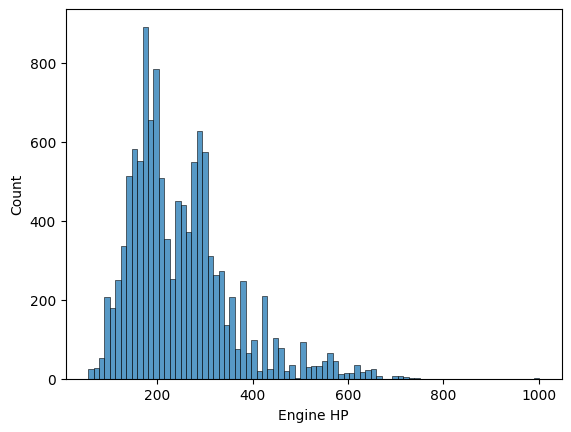

In [11]:
sns.histplot(df['Engine HP'])

In [12]:
df.groupby(df['Engine HP'].isna())['MSRP'].mean() # missing carries a signal (missing value --> lower the MSRP)

Engine HP
False    40547.195610
True     48756.014493
Name: MSRP, dtype: float64

In [13]:
df['Engine_HP_missing'] = df['Engine HP'].isna().astype(int)

In [14]:
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())

In [15]:
df['Market Category'].isnull().mean()*100  # 31% of data values are missing 

np.float64(31.408427060600975)

In [16]:
df['Market Category']=df['Market Category'].fillna(df['Market Category'].mode()[0])

In [17]:
df['Engine Cylinders'].isnull().mean()*100 # 25% of data val are missing 

np.float64(0.2518045996306866)

In [18]:
df['Engine Cylinders']=df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())

In [19]:
df['Engine Cylinders'].mean()

np.float64(5.629763303676347)

<Axes: xlabel='Engine Cylinders', ylabel='Count'>

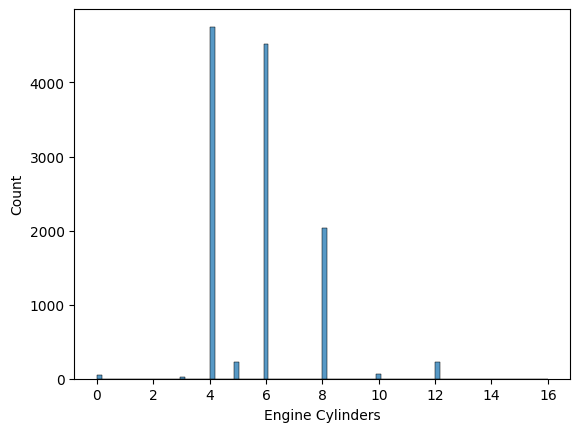

In [20]:
sns.histplot(df['Engine Cylinders'])

In [21]:
df['Number of Doors']=df['Number of Doors'].fillna(3)

In [22]:
df.isnull().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
Engine_HP_missing    0
dtype: int64

<Axes: xlabel='MSRP', ylabel='Count'>

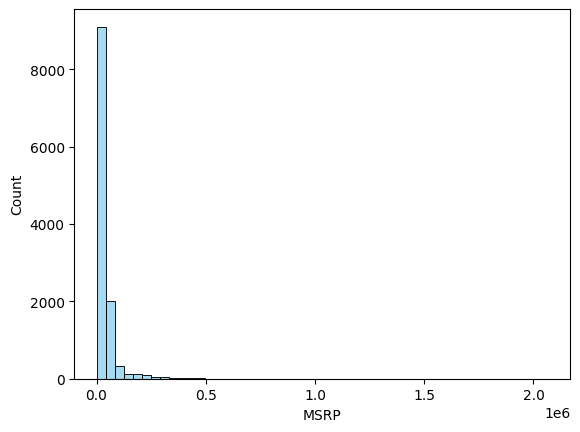

In [23]:
sns.histplot(df['MSRP'], bins=50, color='skyblue') 

<Axes: xlabel='Engine HP', ylabel='Count'>

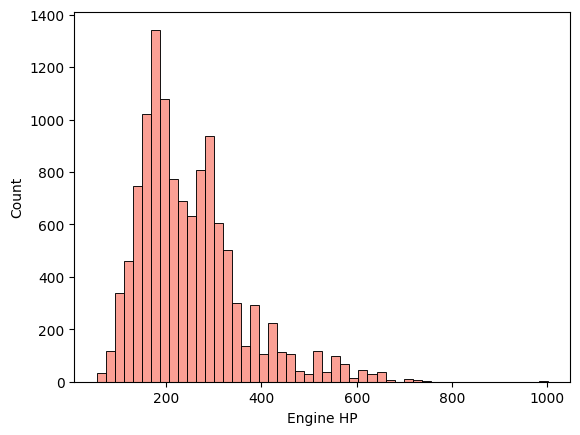

In [24]:
sns.histplot(df['Engine HP'], bins=50, color='salmon')

<Axes: xlabel='highway MPG', ylabel='Count'>

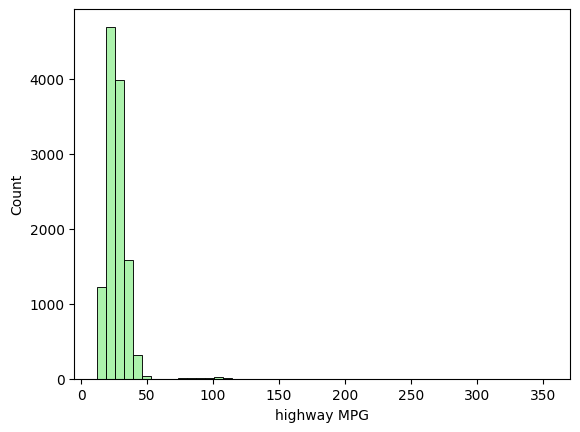

In [25]:
sns.histplot(df['highway MPG'], bins=50, color='lightgreen')